Deep Learning Image Segmentation Pipeline

Kvasir-SEG Polyp Segmentation Project

Candidate Numbers: 2, 6, 17

Task 2: Impact of data augmentation on the final outcome.

In [ ]:
# Core imports
import os, time, random, json, csv
import numpy as np
import pandas as pd

# Imaging + plots
from PIL import Image
import matplotlib.pyplot as plt

# PyTorch stack
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

# Augmentations
import albumentations as A

# Colab installs (quiet)
# timm is often needed by SMP backbones
# --quiet keeps output minimal; remove it if you want logs
!pip install --quiet segmentation_models_pytorch timm

import segmentation_models_pytorch as smp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to working directory from google drive root
base_dir = 'drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/'

# Define subdirectories for results and model checkpoints
RESULTS_DIR = os.path.join(base_dir, "results")
MODELS_DIR = os.path.join(base_dir, "models")

# Create them if they don't already exist
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Results directory: {RESULTS_DIR}")
print(f"Models directory:  {MODELS_DIR}")

Results directory: drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results
Models directory:  drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/models


## Model Baseline Template


###Step 1: Discover dataset files

In [ ]:
# Define paths to images and masks directories
# Using os.path.join for cross-platform compatibility
images_path = os.path.join(base_dir, 'Kvasir-SEG', 'images')
masks_path = os.path.join(base_dir, 'Kvasir-SEG', 'masks')

# Verify that the directories exist before proceeding
if not os.path.exists(images_path):
    raise FileNotFoundError(f"Images directory not found: {images_path}")
if not os.path.exists(masks_path):
    raise FileNotFoundError(f"Masks directory not found: {masks_path}")

# Get list of all files in each directory
images = os.listdir(images_path)
masks = os.listdir(masks_path)

# Filter for JPEG files only (case-insensitive to catch .JPG, .jpeg, etc.)
images_jpg = [f for f in images if f.lower().endswith('.jpg')]
masks_jpg = [f for f in masks if f.lower().endswith('.jpg')]

# Sort the file lists to ensure consistent pairing
images_jpg.sort()
masks_jpg.sort()

print(f"Found {len(images_jpg)} JPG files in images directory.")
print(f"Found {len(masks_jpg)} JPG files in masks directory.")

Found 1000 JPG files in images directory.
Found 1000 JPG files in masks directory.


### Step 2: Defining Class to format input data
Define KvasirSegDataset class + augmentation pipelines

In [ ]:
class KvasirSegDataset(Dataset):
    """
    Custom PyTorch Dataset for Kvasir-SEG medical image segmentation task.

    This dataset loads image-mask pairs from predefined file lists and applies
    specified transformations for data augmentation and preprocessing.

    """
    def __init__(self, file_list_path, img_dir, mask_dir, transform=None):
        """
        Initialize dataset by loading the list of files to process.

        The file list should contain base filenames (without extensions) that
        exist in both the images and masks directories with .jpg extension.
        """
        # Read and store the list of base filenames from the provided text file
        with open(file_list_path, 'r') as f:
            self.file_list = [line.strip() for line in f.readlines()]
                # Store directory paths and transformation pipeline
        self.img_dir = img_dir      # Directory containing input images
        self.mask_dir = mask_dir    # Directory containing ground truth masks
        self.transform = transform  # Albumentations transformation pipeline

    def __len__(self):
        #Return the total number of samples in the dataset.
        return len(self.file_list)

    def __getitem__(self, idx):
        # Resolve file paths (expects .jpg for both image and mask)
        file_name = self.file_list[idx]
        img_full_path = os.path.join(self.img_dir, file_name + '.jpg')
        mask_full_path = os.path.join(self.mask_dir, file_name + '.jpg')

        img = Image.open(img_full_path).convert('RGB') # Ensure image is RGB
        mask = Image.open(mask_full_path).convert('L') # Ensure mask is grayscale

        # Convert PIL images to numpy arrays for albumentations
        img_np = np.array(img)
        mask_np = np.array(mask)

        if self.transform:
            # Apply transformations to both image and mask
            augmented = self.transform(image=img_np, mask=mask_np)
            img_np = augmented['image']
            mask_np = augmented['mask']

        # Convert to tensors
        img = F.to_tensor(img_np)
        mask = torch.from_numpy(mask_np).float()
        return img, mask

# DATA TRANSFORMATION PIPELINES

#Define data augmentation and preprocessing pipelines for training and validation.

#Training typically uses more aggressive augmentations to improve model generalization,
#while validation uses minimal transformations for accurate performance evaluation.

# Geometric transformations
train_transform_geometric = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, p=0.5),
    A.Resize(256,256),
])

# Photometric transformations
train_transform_photometric = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.5),
    A.Resize(256,256),
])

# Noise transformation
train_transform_noise = A.Compose([
    A.GaussNoise(std_range=(0.1, 0.2), p=0.5),
    A.Resize(256,256),
])

# Combined all transfromations
train_transform_combination = A.Compose([
    # Geometric
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, p=0.5),
    # Photometric
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.5),
    # Noise
    A.GaussNoise(std_range=(0.1, 0.2), p=0.5),
    A.Resize(256,256),
])

# No transformations except resizing
val_transform = A.Compose([
    A.Resize(256,256),
])

### Step 3: Instantiate dataset objects

In [ ]:
# Paths to text files with image and mask filenames
train_list_path = base_dir + 'train.txt'
val_list_path = base_dir + 'val.txt'

# Path to images and masks
image_dir = base_dir + 'Kvasir-SEG/images'
mask_dir = base_dir + 'Kvasir-SEG/masks'

# Create dataset instances for each data augmentation.

# No augmentation
train_dataset_baseline = KvasirSegDataset(train_list_path, image_dir, mask_dir, transform=val_transform)

# Geometric augmentation
train_dataset_geometric = KvasirSegDataset(train_list_path, image_dir, mask_dir, transform=train_transform_geometric)

# Photometric augmentation
train_dataset_photometric = KvasirSegDataset(train_list_path, image_dir, mask_dir, transform=train_transform_photometric)

# Noise augmentation
train_dataset_noise = KvasirSegDataset(train_list_path, image_dir, mask_dir, transform=train_transform_noise)

# Combined augmentation
train_dataset_combined = KvasirSegDataset(train_list_path, image_dir, mask_dir, transform=train_transform_combination)

# Validation dataset
val_dataset = KvasirSegDataset(val_list_path, image_dir, mask_dir, transform=val_transform)

###Step 4: Visualize sample resize images

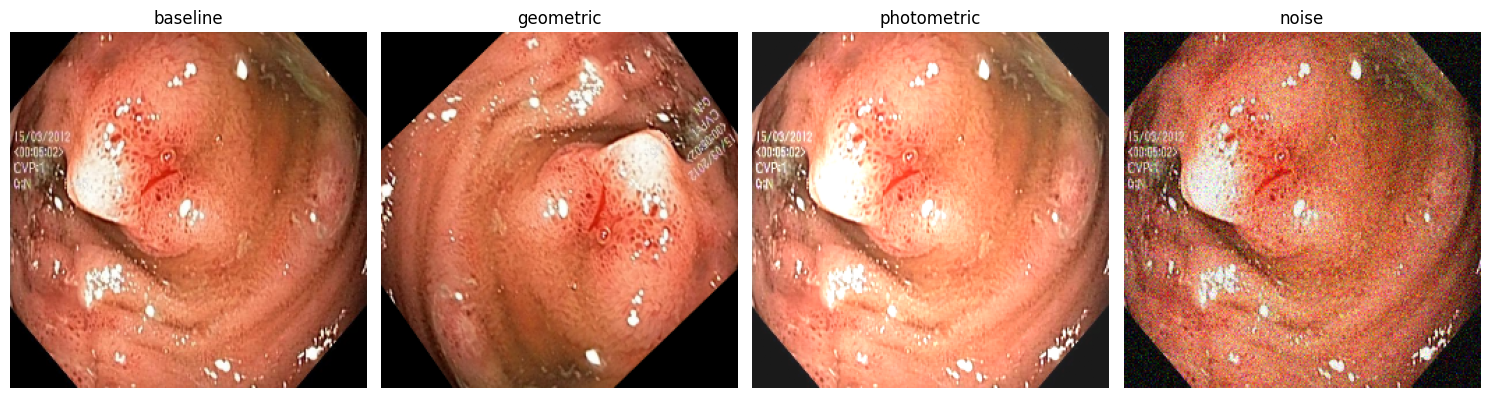

In [ ]:
# Choose index of image to display
idx = 0

# Get images after augmentation
img_baseline,_ = train_dataset_baseline[idx]
img_geometric,_ = train_dataset_geometric[idx]
img_photometric,_ = train_dataset_photometric[idx]
img_noise,_ = train_dataset_noise[idx]

# Display images
images = [
    ('baseline', img_baseline),
    ('geometric', img_geometric),
    ('photometric', img_photometric),
    ('noise', img_noise)
]

plt.figure(figsize=(15, 5))
for i, (title, img) in enumerate(images):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "ResizeImage.png"))
plt.show()


### Step 5: Creating DataLoaders from training and validation datasets

In [ ]:
# Wrap each dataset with a DataLoader for efficient batching and parallel loading.
# - batch_size: number of samples per batch
# - shuffle=True  : randomize order each epoch (training only)
# - num_workers=2 : number of background threads loading data (Colab usually 2–4 is safe)
# - pin_memory=True : speeds up host-to-GPU transfers when using CUDA

# Create dataloaders for each dataset
# No augmentation
train_dataloader_baseline = DataLoader(train_dataset_baseline, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Geometric augmentation
train_dataloader_geometric = DataLoader(train_dataset_geometric, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Photometric augmentation
train_dataloader_photometric = DataLoader(train_dataset_photometric, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Noise augmentation
train_dataloader_noise = DataLoader(train_dataset_noise, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Combined augmenation
train_dataloader_combined = DataLoader(train_dataset_combined, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

# Validation
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

## Training Functionality

### Step 6- Defining early stopping class

In [ ]:
# This class monitors a chosen validation metric (Dice score here) and stops
# training when the model stops improving, helping prevent overfitting and unnecessary computation.

# Early stopping based on validation Dice (higher is better).
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, path=os.path.join(MODELS_DIR, "best_model.pt"), verbose=True):
        # Parameters controlling early stopping behavior
        self.patience = patience          # Number of epochs to wait before stopping
        self.delta = delta                # Minimum required improvement in Dice
        self.path = path                  # Path for saving best model weights
        self.verbose = verbose            # Whether to print status updates
        # Internal tracking variables
        self.best_dice = -np.inf          # Initialize best Dice as negative infinity
        self.counter = 0                  # Counts epochs without improvement
        self.early_stop = False           # Flag indicating when to stop training

    def __call__(self, val_dice, model):
        # Check for improvement in Dice (higher = better)
        if val_dice > self.best_dice + self.delta:
            self.best_dice = val_dice     # Update best score
            self.counter = 0              # Rest patience counter

            # Save model weights
            torch.save(model.state_dict(), self.path)  # Persist model weights/checkpoints
            if self.verbose:
                print(f"Validation Dice improved: {val_dice:.4f}. Model saved.")
        else:
            # No improvement — increment counter
            self.counter += 1
            if self.verbose:
                print(f"No improvement ({self.counter}/{self.patience})")

            # If patience limit reached → trigger early stop
            if self.counter >= self.patience:
                self.early_stop = True


### Step 7 — Custom Loss Function (BCE + Dice)

In [ ]:
# Combines Binary Cross-Entropy (BCE) and Dice loss to balance pixel-wise accuracy
# and region-overlap quality in binary segmentation tasks.

# Calculates Loss with both BCE and dice with default 50/50 weight
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6, bce_weight=0.5, dice_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.smooth = smooth
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets):
        # Ensure targets are float and normalized to [0,1]
        targets = (targets / 255.0).unsqueeze(1)

        # BCE loss
        bce_loss = self.bce(preds, targets)

        # Dice loss
        probs = torch.sigmoid(preds)
        probs_flat = probs.contiguous().view(probs.size(0), -1)
        targets_flat = targets.contiguous().view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(1)
        dice_score = (2. * intersection + self.smooth) / (
            probs_flat.sum(1) + targets_flat.sum(1) + self.smooth
        )
        dice_loss = 1 - dice_score.mean()

        # Weighted sum
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


### Step 8 — Evaluation Metric: Dice Coefficient

In [ ]:
# Computes the Dice coefficient, a measure of overlap between predicted and
# ground-truth masks. Dice = 1 indicates perfect overlap, Dice = 0 means no overlap.

def dice_coefficient(preds, targets, threshold=0.5, smooth=1e-6):
    # Ensure targets are float and scaled
    targets = (targets / 255.0).unsqueeze(1)

    # Convert raw logits to probabilities, then threshold to binary predictions
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    # Flatten both tensors for batch-wise Dice computation
    preds_flat = preds.contiguous().view(preds.size(0), -1)
    targets_flat = targets.contiguous().view(targets.size(0), -1)

    # Intersection and union for Dice score
    intersection = (preds_flat * targets_flat).sum(1)
    dice = (2. * intersection + smooth) / (preds_flat.sum(1) + targets_flat.sum(1) + smooth)

    # Return average Dice across the batch (as a Python float)
    return dice.mean().item()

### Step 9 — Training Loop Function (Single Epoch)

In [ ]:
# Performs one full pass over the training dataset (one epoch).
# For each batch:
#   - Moves images/masks to the GPU (if available)
#   - Computes model predictions and loss
#   - Backpropagates gradients and updates weights
#   - Tracks average loss and Dice score across all batches

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # Enable dropout/batchnorm for training
    running_loss = 0.0
    running_dice = 0.0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        # --- Forward + backward pass ---
        optimizer.zero_grad()           # Reset gradient buffers before next step
        preds = model(imgs)             # Forward pass (get logits)
        loss = criterion(preds, masks)  # Compute loss
        loss.backward()                 # Backpropagate gradients
        optimizer.step()                # Update parameters

        # --- Track loss ---
        running_loss += loss.item()

        # --- Compute training Dice (without affecting gradients) ---
        with torch.no_grad():
            dice = dice_coefficient(preds, masks)
            running_dice += dice

        # --- Average metrics across all batches ---
        train_loss = running_loss / len(loader)
        train_dice = running_dice / len(loader)

    return train_loss, train_dice

### Step 10 — Validation Loop Function (Model Evaluation per Epoch)

In [ ]:
# Evaluates the model on the validation set at the end of each epoch.
# No gradients are computed, so this runs faster and uses less memory.

def validate(model, loader, criterion, device):
    model.eval()  # Disable dropout, use running stats for batchnorm
    val_loss = 0.0
    val_dice = 0.0

    # Disable gradient computation for faster, memory-efficient inference
    with torch.no_grad():  # Inference mode: no gradients for speed/memory
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            # Forward pass only (no backward)
            preds = model(imgs)
            loss = criterion(preds, masks)
            val_loss += loss.item()
            # Compute Dice score for evaluation
            dice = dice_coefficient(preds, masks)
            val_dice += dice

    # Average metrics across all batches
    val_loss /= len(loader)
    val_dice /= len(loader)
    return val_loss, val_dice

### Step 11 — Full Training Loop (multi-epoch, with scheduler + early stopping)

In [ ]:
# Orchestrates the end-to-end training for multiple epochs:
#   - trains for one epoch
#   - evaluates on the validation set
#   - steps the LR scheduler
#   - logs metrics
#   - applies early stopping based on validation Dice

def run_training(model, train_loader, val_loader, optimizer, criterion, early_stopper, scheduler, device, num_epochs=20):

    # Dictionary to log metrics
    history = {
        "train_loss": [],
        "train_dice": [],
        "val_loss": [],
        "val_dice": []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # Training phase (updates weights)
        train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion, device)

        # Validation phase
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        # Log metrics for this epoch
        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

        # Early stopping: saves best model and stops if no improvement
        early_stopper(val_dice, model)
        if early_stopper.early_stop:
            print("Early stopping triggered.")
            break

    print("\nTraining complete.")
    print(f"Best Validation Dice: {early_stopper.best_dice:.4f}")
    return history

### Saves history to CSV, and plots loss/Dice curves as PNGs.

In [ ]:
def save_and_plot_history(history, RESULTS_DIR, prefix="run"):

    os.makedirs(RESULTS_DIR, exist_ok=True)

    # Save CSV
    csv_path = os.path.join(RESULTS_DIR, f"{prefix}_history.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "train_dice", "val_loss", "val_dice"])
        n = len(history["train_loss"])
        for i in range(n):
            writer.writerow([
                i + 1,
                history["train_loss"][i],
                history["train_dice"][i],
                history["val_loss"][i],
                history["val_dice"][i],
            ])
    print(f"Saved history CSV  → {csv_path}")

    # Plot Loss
    plt.figure(figsize=(7, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    loss_png = os.path.join(RESULTS_DIR, f"{prefix}_loss_curve.png")
    plt.savefig(loss_png, dpi=150)
    plt.close()
    print(f" Saved loss curve   → {loss_png}")

    # Plot Dice
    plt.figure(figsize=(7, 5))
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"],   label="Validation Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Coefficient")
    plt.title("Training vs Validation Dice")
    plt.legend()
    plt.tight_layout()
    dice_png = os.path.join(RESULTS_DIR, f"{prefix}_dice_curve.png")
    plt.savefig(dice_png, dpi=150)
    plt.close()
    print(f"Saved Dice curve   → {dice_png}")


## Creating Models

### Step 12 — Training Configuration and Device Setup

In [ ]:
# Choose device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Choose starting number of epochs to train
NUM_EPOCHS = 50

# Choose starting learning rate
LR = 1e-3

# Print device
print(f"Using device: {DEVICE}")

Using device: cuda


### Step 13: Explore the impact of data augmentation


1.   baseline
2.   geometric augmentation
3.   photometric augmentation
4.   noise augmentation
5.   combined augmentation







### 1. Baseline

In [ ]:
# Create Unet model
model_unet_baseline = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,    # Three channels for RGB input
    classes=1,        # One channel for binary segmentation
    activation=None
)
model_unet_baseline.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_baseline = optim.Adam(model_unet_baseline.parameters(), lr=LR)  # Instantiate optimizer with hyperparameters

# Early stopper
early_stopper = EarlyStopping(patience=5, delta=0.001, path=os.path.join(MODELS_DIR, f"unet_resnet34_baseline_best.pt"), verbose=True)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_baseline, mode='max', factor=0.5, patience=3, min_lr=1e-7)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

#### Train Model : baseline

In [ ]:
# Run Training
history_baseline = run_training(
    model_unet_baseline,
    train_dataloader_baseline,
    val_dataloader,
    optimizer_unet_baseline,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS)


Epoch 1/50
----------------------------------------
Train Loss: 0.3870 | Val Loss: 0.3280 | Val Dice: 0.6938
Validation Dice improved: 0.6938. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2148 | Val Loss: 0.4665 | Val Dice: 0.4943
No improvement (1/5)

Epoch 3/50
----------------------------------------
Train Loss: 0.2005 | Val Loss: 0.2886 | Val Dice: 0.7345
Validation Dice improved: 0.7345. Model saved.

Epoch 4/50
----------------------------------------
Train Loss: 0.1657 | Val Loss: 0.2640 | Val Dice: 0.7468
Validation Dice improved: 0.7468. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.1400 | Val Loss: 0.3048 | Val Dice: 0.7327
No improvement (1/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1389 | Val Loss: 0.2688 | Val Dice: 0.7549
Validation Dice improved: 0.7549. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.0978 | Val Loss: 0.2152 | Val Dice: 0.8062


####Save result : baseline

In [ ]:
# Save metrics and plots to results/ folder
save_and_plot_history(history_baseline,RESULTS_DIR, prefix="unet_resnet34_augmentation_baseline")

Saved history CSV  → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_baseline_history.csv
 Saved loss curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_baseline_loss_curve.png
Saved Dice curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_baseline_dice_curve.png


In [ ]:
# Define path to saved history file
history_path = os.path.join(RESULTS_DIR, "unet_resnet34_augmentation_baseline_history.csv")

# Load CSV as DataFrame
history_df = pd.read_csv(history_path)

# Convert DataFrame to dictionary
history_baseline = {col: history_df[col].tolist() for col in history_df.columns}

print("Loaded history keys:", history_baseline.keys())
print("Number of epochs:", len(history_baseline["train_loss"]))

Loaded history keys: dict_keys(['epoch', 'train_loss', 'train_dice', 'val_loss', 'val_dice'])
Number of epochs: 17


### 2. Geometric augmentation

In [ ]:
# Create Unet model
model_unet_geometric = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,    # Three channels for RGB input
    classes=1,        # One channel for binary segmentation
    activation=None
)
model_unet_geometric.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_geometric = optim.Adam(model_unet_geometric.parameters(), lr=LR)  # Instantiate optimizer with hyperparameters

# Early stopper
early_stopper = EarlyStopping(patience=5, delta=0.001, path=os.path.join(MODELS_DIR, "unet_resnet34_geometric_augmentation_best.pt"), verbose=True)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_geometric, mode='max', factor=0.5, patience=3, min_lr=1e-7)

#### Train Model : geometric augmentation

In [ ]:
# Run training
history_geometric = run_training(
    model_unet_geometric,
    train_dataloader_geometric,
    val_dataloader,
    optimizer_unet_geometric,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS)


Epoch 1/50
----------------------------------------
Train Loss: 0.4097 | Val Loss: 0.3174 | Val Dice: 0.7025
Validation Dice improved: 0.7025. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2510 | Val Loss: 0.2995 | Val Dice: 0.7327
Validation Dice improved: 0.7327. Model saved.

Epoch 3/50
----------------------------------------
Train Loss: 0.2329 | Val Loss: 0.2464 | Val Dice: 0.7676
Validation Dice improved: 0.7676. Model saved.

Epoch 4/50
----------------------------------------
Train Loss: 0.1993 | Val Loss: 0.3510 | Val Dice: 0.6711
No improvement (1/5)

Epoch 5/50
----------------------------------------
Train Loss: 0.1940 | Val Loss: 0.2628 | Val Dice: 0.7629
No improvement (2/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1876 | Val Loss: 0.2524 | Val Dice: 0.7832
Validation Dice improved: 0.7832. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.1714 | Val Loss: 0.2673 | Val Dice: 0.7767


####Save result : geometric augmentation

In [ ]:
# Save metrics and plots to your results/ folder
save_and_plot_history(history_geometric,RESULTS_DIR, prefix="unet_resnet34_augmentation_geometric")

Saved history CSV  → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_geometric_history.csv
 Saved loss curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_geometric_loss_curve.png
Saved Dice curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_geometric_dice_curve.png


In [ ]:
# Define path to saved history file
history_path = os.path.join(RESULTS_DIR, "unet_resnet34_augmentation_geometric_history.csv")

# Load CSV as DataFrame
history_df = pd.read_csv(history_path)

# Convert DataFrame to dictionary
history_geometric = {col: history_df[col].tolist() for col in history_df.columns}

print("Loaded history keys:", history_geometric.keys())
print("Number of epochs:", len(history_geometric["train_loss"]))

Loaded history keys: dict_keys(['epoch', 'train_loss', 'train_dice', 'val_loss', 'val_dice'])
Number of epochs: 27


### 3. Photometric augmentation

In [ ]:
# Create Unet model
model_unet_photometric = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,    # Three channels for RGB input
    classes=1,        # One channel for binary segmentation
    activation=None
)
model_unet_photometric.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_photometric = optim.Adam(model_unet_photometric.parameters(), lr=LR)  # Instantiate optimizer with hyperparameters

# Early stopper
early_stopper = EarlyStopping(patience=5, delta=0.001, path=os.path.join(MODELS_DIR, "unet_resnet34_photometric_augmentation_best.pt"), verbose=True)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_photometric, mode='max', factor=0.5, patience=3, min_lr=1e-7)

#### Train Model : photometric augmentation

In [ ]:
# Run Training
history_photometric = run_training(
    model_unet_photometric,
    train_dataloader_photometric,
    val_dataloader,
    optimizer_unet_photometric,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS)


Epoch 1/50
----------------------------------------
Train Loss: 0.3775 | Val Loss: 0.3177 | Val Dice: 0.7120
Validation Dice improved: 0.7120. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2217 | Val Loss: 0.2956 | Val Dice: 0.7331
Validation Dice improved: 0.7331. Model saved.

Epoch 3/50
----------------------------------------
Train Loss: 0.1766 | Val Loss: 0.2624 | Val Dice: 0.7612
Validation Dice improved: 0.7612. Model saved.

Epoch 4/50
----------------------------------------
Train Loss: 0.1706 | Val Loss: 0.2478 | Val Dice: 0.7798
Validation Dice improved: 0.7798. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.1445 | Val Loss: 0.2494 | Val Dice: 0.7769
No improvement (1/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1316 | Val Loss: 0.2387 | Val Dice: 0.7870
Validation Dice improved: 0.7870. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.0983 | Val Loss: 

####Save result : photometric augmentation

In [ ]:
# Save metrics and plots to your results/ folder
save_and_plot_history(history_photometric,RESULTS_DIR, prefix="unet_resnet34_augmentation_photometric")

Saved history CSV  → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_photometric_history.csv
 Saved loss curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_photometric_loss_curve.png
Saved Dice curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_photometric_dice_curve.png


In [ ]:
# Define path to saved history file
history_path = os.path.join(RESULTS_DIR, "unet_resnet34_augmentation_photometric_history.csv")

# Load CSV as DataFrame
history_df = pd.read_csv(history_path)

# Convert DataFrame to dictionary
history_photometric = {col: history_df[col].tolist() for col in history_df.columns}

print("Loaded history keys:", history_photometric.keys())
print("Number of epochs:", len(history_photometric["train_loss"]))

Loaded history keys: dict_keys(['epoch', 'train_loss', 'train_dice', 'val_loss', 'val_dice'])
Number of epochs: 16


### 4. Noise augmentation

In [ ]:
# Create Unet model
model_unet_noise = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,    # Three channels for RGB input
    classes=1,        # One channel for binary segmentation
    activation=None
)
model_unet_noise.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_noise = optim.Adam(model_unet_noise.parameters(), lr=LR)  # Instantiate optimizer with hyperparameters

# Early stopper
early_stopper = EarlyStopping(patience=5, delta=0.001, path=os.path.join(MODELS_DIR, f"unet_resnet34_noise_augmentation_best.pt"), verbose=True)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_noise, mode='max', factor=0.5, patience=3, min_lr=1e-7)

#### Train Model : noise augmentation

In [ ]:
# Run Training
history_noise = run_training(
    model_unet_noise,
    train_dataloader_noise,
    val_dataloader,
    optimizer_unet_noise,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS)


Epoch 1/50
----------------------------------------
Train Loss: 0.4304 | Val Loss: 0.3560 | Val Dice: 0.6557
Validation Dice improved: 0.6557. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2585 | Val Loss: 0.3248 | Val Dice: 0.7077
Validation Dice improved: 0.7077. Model saved.

Epoch 3/50
----------------------------------------
Train Loss: 0.2283 | Val Loss: 0.2738 | Val Dice: 0.7572
Validation Dice improved: 0.7572. Model saved.

Epoch 4/50
----------------------------------------
Train Loss: 0.1864 | Val Loss: 0.2728 | Val Dice: 0.7545
No improvement (1/5)

Epoch 5/50
----------------------------------------
Train Loss: 0.1761 | Val Loss: 0.3899 | Val Dice: 0.6691
No improvement (2/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1729 | Val Loss: 0.2410 | Val Dice: 0.7657
Validation Dice improved: 0.7657. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.1460 | Val Loss: 0.2647 | Val Dice: 0.7728


####Save result : noise augmentation

In [ ]:
# Save metrics and plots to your results/ folder
save_and_plot_history(history_noise,RESULTS_DIR, prefix="unet_resnet34_augmentation_noise")

Saved history CSV  → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_noise_history.csv
 Saved loss curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_noise_loss_curve.png
Saved Dice curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_noise_dice_curve.png


In [ ]:
# Define path to saved history file
history_path = os.path.join(RESULTS_DIR, "unet_resnet34_augmentation_noise_history.csv")

# Load CSV as DataFrame
history_df = pd.read_csv(history_path)

# Convert DataFrame to dictionary
history_noise = {col: history_df[col].tolist() for col in history_df.columns}

print("Loaded history keys:", history_noise.keys())
print("Number of epochs:", len(history_noise["train_loss"]))

Loaded history keys: dict_keys(['epoch', 'train_loss', 'train_dice', 'val_loss', 'val_dice'])
Number of epochs: 17


### Combined augmentation

In [ ]:
# Create Unet model
model_unet_combined = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,    # Three channels for RGB input
    classes=1,        # One channel for binary segmentation
    activation=None
)
model_unet_combined.to(DEVICE)

# Loss
criterion = BCEDiceLoss()

# Optimizer
optimizer_unet_combined = optim.Adam(model_unet_combined.parameters(), lr=LR)  # Instantiate optimizer with hyperparameters

# Early stopper
early_stopper = EarlyStopping(patience=5, delta=0.001, path=os.path.join(MODELS_DIR, f"unet_resnet34_combined_augmentation_best.pt"), verbose=True)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_unet_combined, mode='max', factor=0.5, patience=3, min_lr=1e-7)

#### Train Model : combined augmentation

In [ ]:
# Run Training
history_combined = run_training(
    model_unet_combined,
    train_dataloader_combined,
    val_dataloader,
    optimizer_unet_combined,
    criterion,
    early_stopper,
    scheduler,
    DEVICE,
    NUM_EPOCHS)


Epoch 1/50
----------------------------------------
Train Loss: 0.4540 | Val Loss: 0.3578 | Val Dice: 0.6569
Validation Dice improved: 0.6569. Model saved.

Epoch 2/50
----------------------------------------
Train Loss: 0.2885 | Val Loss: 0.3104 | Val Dice: 0.7171
Validation Dice improved: 0.7171. Model saved.

Epoch 3/50
----------------------------------------
Train Loss: 0.2440 | Val Loss: 0.3035 | Val Dice: 0.6991
No improvement (1/5)

Epoch 4/50
----------------------------------------
Train Loss: 0.2317 | Val Loss: 0.2629 | Val Dice: 0.7609
Validation Dice improved: 0.7609. Model saved.

Epoch 5/50
----------------------------------------
Train Loss: 0.2203 | Val Loss: 0.2581 | Val Dice: 0.7587
No improvement (1/5)

Epoch 6/50
----------------------------------------
Train Loss: 0.1943 | Val Loss: 0.2070 | Val Dice: 0.8141
Validation Dice improved: 0.8141. Model saved.

Epoch 7/50
----------------------------------------
Train Loss: 0.1790 | Val Loss: 0.1988 | Val Dice: 0.8118


#### Save result : combined augmentation

In [ ]:
# Save metrics and plots to your results/ folder
save_and_plot_history(history_combined,RESULTS_DIR, prefix="unet_resnet34_augmentation_combined")

Saved history CSV  → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_combined_history.csv
 Saved loss curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_combined_loss_curve.png
Saved Dice curve   → drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/unet_resnet34_augmentation_combined_dice_curve.png


In [ ]:
# Define path to saved history file
history_path = os.path.join(RESULTS_DIR, "unet_resnet34_augmentation_combined_history.csv")

# Load CSV as DataFrame
history_df = pd.read_csv(history_path)

# Convert DataFrame to dictionary
history_combined = {col: history_df[col].tolist() for col in history_df.columns}

print("Loaded history keys:", history_combined.keys())
print("Number of epochs:", len(history_combined["train_loss"]))

Loaded history keys: dict_keys(['epoch', 'train_loss', 'train_dice', 'val_loss', 'val_dice'])
Number of epochs: 26


## Step 14: Visualizing Model Performance

### Training and Validation Loss and Dice coefficient Plot history

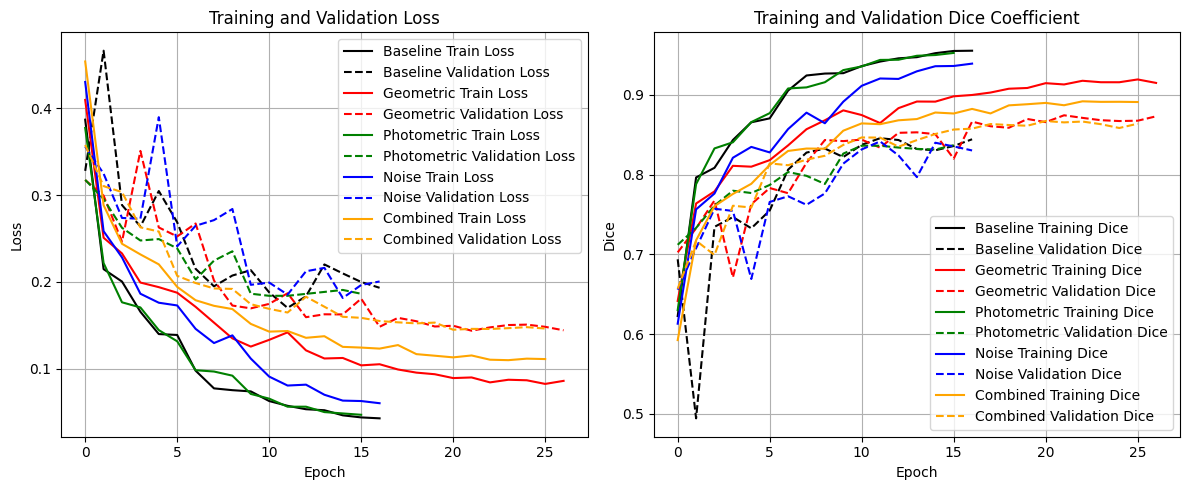

In [ ]:
plt.figure(figsize=(12, 5))

# Left subplot: Loss curves
plt.subplot(1, 2, 1)

plt.plot(history_baseline['train_loss'], label='Baseline Train Loss', color='black')
plt.plot(history_baseline['val_loss'], label='Baseline Validation Loss', color='black', linestyle='--')

plt.plot(history_geometric['train_loss'], label='Geometric Train Loss', color='red')
plt.plot(history_geometric['val_loss'], label='Geometric Validation Loss', color='red', linestyle='--')

plt.plot(history_photometric['train_loss'], label='Photometric Train Loss', color='green')
plt.plot(history_photometric['val_loss'], label='Photometric Validation Loss', color='green', linestyle='--')

plt.plot(history_noise['train_loss'], label='Noise Train Loss', color='blue')
plt.plot(history_noise['val_loss'], label='Noise Validation Loss', color='blue', linestyle='--')

plt.plot(history_combined['train_loss'], label='Combined Train Loss', color='orange')
plt.plot(history_combined['val_loss'], label='Combined Validation Loss', color='orange', linestyle='--')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

 # Right subplot: Dice coefficient
plt.subplot(1, 2, 2)

plt.plot(history_baseline['train_dice'], label='Baseline Training Dice', color='black')
plt.plot(history_baseline['val_dice'], label='Baseline Validation Dice',color='black', linestyle='--')

plt.plot(history_geometric['train_dice'], label='Geometric Training Dice', color='red')
plt.plot(history_geometric['val_dice'], label='Geometric Validation Dice',color='red', linestyle='--')

plt.plot(history_photometric['train_dice'], label='Photometric Training Dice', color='green')
plt.plot(history_photometric['val_dice'], label='Photometric Validation Dice',color='green', linestyle='--')

plt.plot(history_noise['train_dice'], label='Noise Training Dice', color='blue')
plt.plot(history_noise['val_dice'], label='Noise Validation Dice',color='blue', linestyle='--')

plt.plot(history_combined['train_dice'], label='Combined Training Dice', color='orange')
plt.plot(history_combined['val_dice'], label='Combined Validation Dice',color='orange', linestyle='--')

plt.title('Training and Validation Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "resize_train&Valid_Loss_accuracy.png"))
plt.show()

In [ ]:
# Create a summary comparison of best validation Dice scores
best_dice_baseline = max(history_baseline['val_dice'])
best_dice_geometric = max(history_geometric['val_dice'])
best_dice_photometric = max(history_photometric['val_dice'])
best_dice_noise = max(history_noise['val_dice'])
best_dice_combined = max(history_combined['val_dice'])

# Create summary table
summary_data = {
    'Augmentation': ['None', 'Geometric', 'Photometric', 'Noise', 'Combined'],
    'Best Validation Dice': [
        best_dice_baseline,
        best_dice_geometric,
        best_dice_photometric,
        best_dice_noise,
        best_dice_combined
    ],
    'Epochs Trained': [
        len(history_baseline['val_dice']),
        len(history_geometric['val_dice']),
        len(history_photometric['val_dice']),
        len(history_noise['val_dice']),
        len(history_combined['val_dice'])
    ]
}

# Print summary table
print("\n" + "="*50)
print("SUMMARY: Impact of Data Augmentation")
print("="*50)
print(f"{'Augmentation':<15} {'Best Val Dice':<15} {'Epochs':<10}")
print("-"*50)
for i in range(len(summary_data['Augmentation'])):
    print(f"{summary_data['Augmentation'][i]:<15} "
          f"{summary_data['Best Validation Dice'][i]:<15.4f} "
          f"{summary_data['Epochs Trained'][i]:<10}")
print("="*50)

# Save summary to CSV
df = pd.DataFrame(summary_data)
df.to_csv(os.path.join(RESULTS_DIR, "summary_augmentation.csv"), index=False)

print("Summary saved to ->", os.path.join(RESULTS_DIR, "summary_augmentation.csv"))


SUMMARY: Impact of Data Augmentation
Augmentation    Best Val Dice   Epochs    
--------------------------------------------------
None            0.8457          17        
Geometric       0.8744          27        
Photometric     0.8369          16        
Noise           0.8416          17        
Combined        0.8672          26        
Summary saved to -> drive/MyDrive/Colab Notebooks/BDS/Fifth_semester/Deep Learning/Exam/results/summary_augmentation.csv


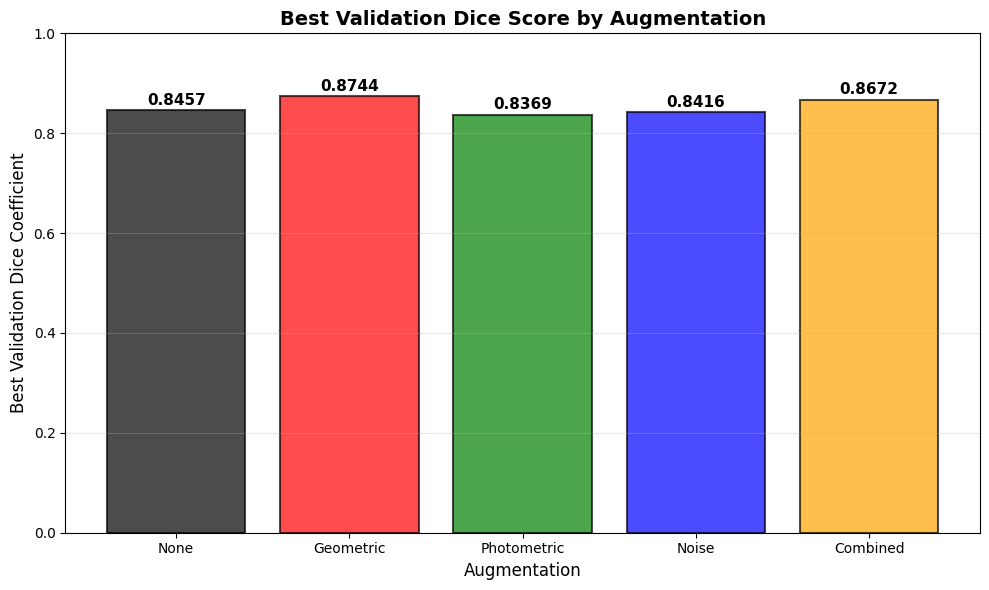

In [ ]:
# Visualize best validation Dice scores as a bar chart
plt.figure(figsize=(10, 6))
augmentation = ['None', 'Geometric', 'Photometric', 'Noise', 'Combined']
best_dice_scores = [best_dice_baseline, best_dice_geometric, best_dice_photometric, best_dice_noise, best_dice_combined]
colors = ['black', 'red', 'green', 'blue', 'orange']

bars = plt.bar(augmentation, best_dice_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, best_dice_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Best Validation Dice Score by Augmentation', fontsize=14, fontweight='bold')
plt.xlabel('Augmentation', fontsize=12)
plt.ylabel('Best Validation Dice Coefficient', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "augmentation_best_dice_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

### Predicted masks in different image resolutions

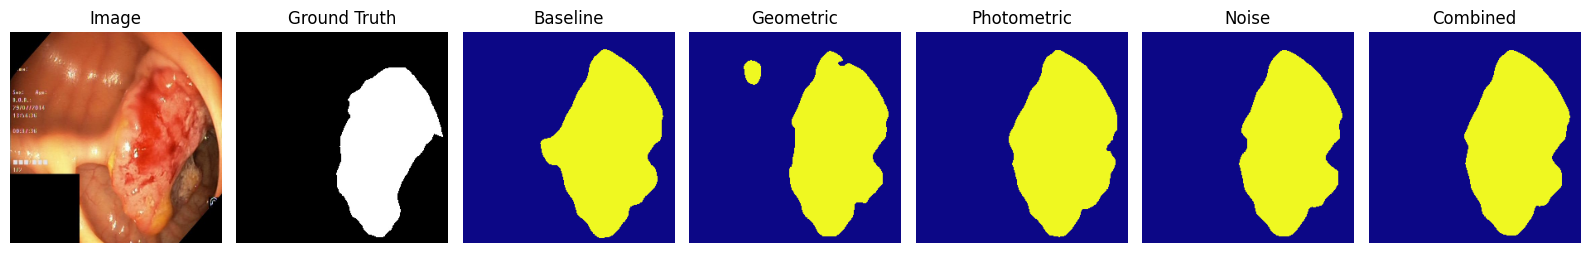

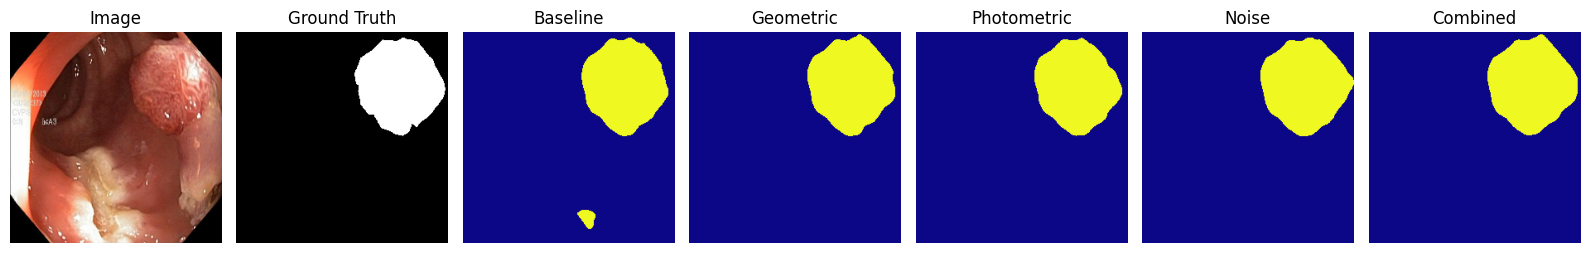

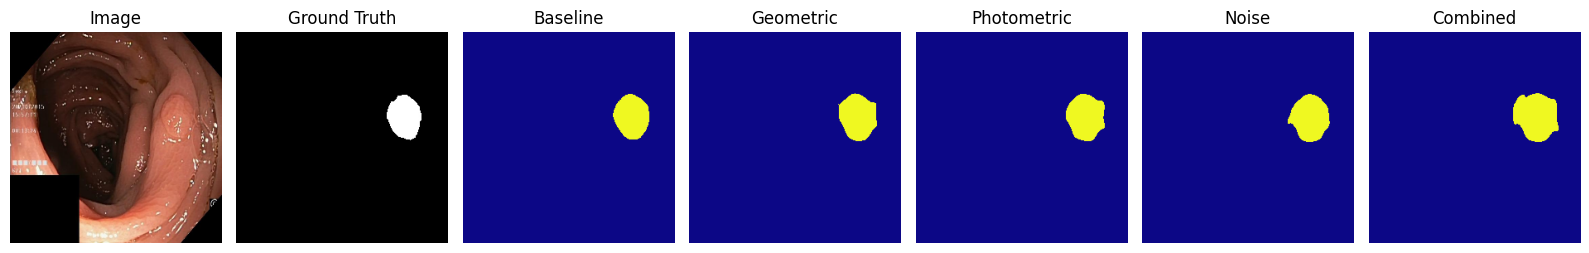

In [ ]:
# Make sure all models are in eval mode
model_unet_baseline.eval()
model_unet_geometric.eval()
model_unet_photometric.eval()
model_unet_noise.eval()
model_unet_combined.eval()

# Get one batch from val_dataloader, all predictions will be with input size 256x256
imgs, masks = next(iter(val_dataloader))

# Pick 3 random indices from the batch
indices = random.sample(range(imgs.size(0)), 3)

for idx, i in enumerate(indices):
    img = imgs[i].to(DEVICE)      # (3,H,W)
    mask = masks[i].to(DEVICE)    # (1,H,W)

    with torch.no_grad():
        # Baseline predictions
        pred_unet_baseline = model_unet_baseline(img.unsqueeze(0))
        pred_unet_baseline = torch.sigmoid(pred_unet_baseline)[0,0]
        pred_unet_baseline = (pred_unet_baseline > 0.5).float()

        # Geometric predictions
        pred_unet_geometric = model_unet_geometric(img.unsqueeze(0))
        pred_unet_geometric = torch.sigmoid(pred_unet_geometric)[0,0]
        pred_unet_geometric = (pred_unet_geometric > 0.5).float()

        # Photometric predictions
        pred_unet_photometric = model_unet_photometric(img.unsqueeze(0))
        pred_unet_photometric = torch.sigmoid(pred_unet_photometric)[0,0]
        pred_unet_photometric = (pred_unet_photometric > 0.5).float()

        # Noise predictions
        pred_unet_noise = model_unet_noise(img.unsqueeze(0))
        pred_unet_noise = torch.sigmoid(pred_unet_noise)[0,0]
        pred_unet_noise = (pred_unet_noise > 0.5).float()

        # Combined predictions
        pred_unet_combined = model_unet_combined(img.unsqueeze(0))
        pred_unet_combined = torch.sigmoid(pred_unet_combined)[0,0]
        pred_unet_combined = (pred_unet_combined > 0.5).float()

    # Convert to numpy for plotting
    img_np = img.permute(1,2,0).cpu().numpy()
    mask_np = mask.squeeze().cpu().numpy()
    pred_unet_baseline_np = pred_unet_baseline.squeeze().cpu().numpy()
    pred_unet_geometric_np = pred_unet_geometric.squeeze().cpu().numpy()
    pred_unet_photometric_np = pred_unet_photometric.squeeze().cpu().numpy()
    pred_unet_noise_np = pred_unet_noise.squeeze().cpu().numpy()
    pred_unet_combined_np = pred_unet_combined.squeeze().cpu().numpy()

    # Plot 1x7 of all predictions
    fig, axes = plt.subplots(1, 7, figsize=(16, 4))
    axes[0].imshow(img_np)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask_np, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred_unet_baseline_np, cmap="plasma")
    axes[2].set_title("Baseline")
    axes[2].axis("off")

    axes[3].imshow(pred_unet_geometric_np, cmap="plasma")
    axes[3].set_title("Geometric")
    axes[3].axis("off")

    axes[4].imshow(pred_unet_photometric_np, cmap="plasma")
    axes[4].set_title("Photometric")
    axes[4].axis("off")

    axes[5].imshow(pred_unet_noise_np, cmap="plasma")
    axes[5].set_title("Noise")
    axes[5].axis("off")

    axes[6].imshow(pred_unet_combined_np, cmap="plasma")
    axes[6].set_title("Combined")
    axes[6].axis("off")

    plt.tight_layout()

    plt.savefig(os.path.join(RESULTS_DIR, f"augmentation_prediction_comparison_{idx + 1}.png"))
    plt.show()